# 12.2 確率的主成分分析と因子分析 (Probabilistic PCA & Factor Analysis)

本ノートブックでは、主成分分析を明確な確率的生成モデルとして再定式化した **確率的主成分分析 (Probabilistic PCA: PPCA)** を学びます。
ガウス潜在変数 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ と線形射影 $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}$（**PRML Figure 12.9, 12.10**）、Tipping & Bishop (1999) によるクローズドフォーム最尤解（$\mathbf{W}_{\mathrm{ML}}, \sigma^2_{\mathrm{ML}}$）、**PPCA の EM アルゴリズム（PRML 12.2.2）** の完全実装と対数尤度の単調収束、ノイズ分散 $\sigma^2 \to 0$ での標準直交射影PCAへの漸近一致性、および異分散ノイズを許容する **因子分析 (Factor Analysis)** の数理的比較を完全実装します。

## 12.2.1 確率的生成モデルの幾何学 (PRML Figure 12.9)

PPCA は以下の2段階生成プロセスです：
1. 潜在空間から低次元ベクトルを生成: $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_M)$
2. 線形射影と等方性ガウスノイズを付加: $\mathbf{x} | \mathbf{z} \sim \mathcal{N}(\mathbf{W}\mathbf{z} + \boldsymbol{\mu}, \sigma^2 \mathbf{I}_D)$

潜在空間の単位円が $\mathbf{W}$ により $D$ 次元空間内の $M$ 次元超平面（主部分空間）へと引き伸ばされ、その周囲に等方ノイズ球が付加される幾何学的構造をプロットします。

Plot saved to: result/fig12_9_ppca_generative_geometry.png


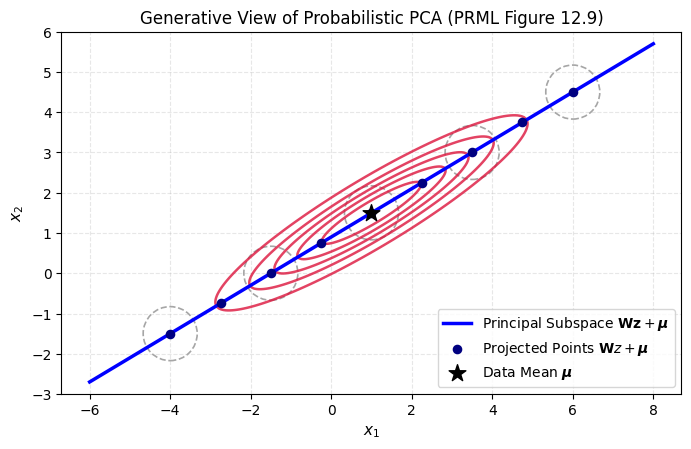

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from common.plot_utils import save_plot, setup_style
from common.pca_ppca_utils import ProbabilisticPCA
setup_style()

# 2次元データ空間 D=2, 1次元潜在空間 M=1
np.random.seed(42)
mu_true = np.array([1.0, 1.5])
W_true = np.array([[2.0], [1.2]]) # 主方向ベクトル
sigma2_true = 0.2

# 潜在空間のグリッド z in [-2.5, 2.5]
z_vals = np.linspace(-2.5, 2.5, 9)
mapped_pts = mu_true + (W_true @ z_vals[np.newaxis, :]).T

# 周辺分布 C = W W^T + sigma^2 I
C_cov = W_true @ W_true.T + sigma2_true * np.eye(2)

# グリッド等高線
x1_grid = np.linspace(-4.5, 6.5, 200)
x2_grid = np.linspace(-3.0, 6.0, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
pos = np.dstack((X1, X2))
dens_marginal = multivariate_normal.pdf(pos, mean=mu_true, cov=C_cov)

# PRML Figure 12.9 のプロット
fig, ax = plt.subplots(figsize=(8, 6.5))

# 周辺密度等高線
ax.contour(X1, X2, dens_marginal, levels=6, colors='crimson', linewidths=1.8, alpha=0.8)

# 主部分空間の直線
z_line = np.linspace(-3.5, 3.5, 100)
line_pts = mu_true + (W_true @ z_line[np.newaxis, :]).T
ax.plot(line_pts[:, 0], line_pts[:, 1], 'b-', lw=2.5, label=r'Principal Subspace $\mathbf{W}\mathbf{z} + \boldsymbol{\mu}$')

# 潜在点からの等方性ノイズ円
for pt in mapped_pts[::2]:
    circle = plt.Circle(pt, radius=np.sqrt(sigma2_true) * 1.5, color='gray', fill=False, linestyle='--', lw=1.2, alpha=0.7)
    ax.add_patch(circle)
ax.scatter(mapped_pts[:, 0], mapped_pts[:, 1], color='navy', s=35, zorder=5, label=r'Projected Points $\mathbf{W}z + \boldsymbol{\mu}$')
ax.scatter(mu_true[0], mu_true[1], color='black', marker='*', s=160, zorder=6, label=r'Data Mean $\boldsymbol{\mu}$')

ax.set_title('Generative View of Probabilistic PCA (PRML Figure 12.9)', fontsize=12)
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_aspect('equal', 'box')
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig12_9_ppca_generative_geometry.png')
plt.show()

## 12.2.2 PPCA に対する EM アルゴリズム

高次元データ（$D$ が極めて大きい）や欠損値が存在する場合、固有値分解を行う標準PCAよりも EM アルゴリズムによる反復学習が計算量的に極めて有利となります。
- **Eステップ**:
  $$ \mathbf{M} = \mathbf{W}^{\mathrm{T}}\mathbf{W} + \sigma^2 \mathbf{I}_M $$
  $$ \mathbb{E}[\mathbf{z}_n] = \mathbf{M}^{-1}\mathbf{W}^{\mathrm{T}}(\mathbf{x}_n - \bar{\mathbf{x}}) $$
  $$ \mathbb{E}[\mathbf{z}_n \mathbf{z}_n^{\mathrm{T}}] = \sigma^2 \mathbf{M}^{-1} + \mathbb{E}[\mathbf{z}_n]\mathbb{E}[\mathbf{z}_n]^{\mathrm{T}} $$
- **Mステップ**:
  $$ \mathbf{W}_{\mathrm{new}} = \left( \sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})\mathbb{E}[\mathbf{z}_n]^{\mathrm{T}} \right) \left( \sum_{n=1}^N \mathbb{E}[\mathbf{z}_n \mathbf{z}_n^{\mathrm{T}}] \right)^{-1} $$
  $$ \sigma_{\mathrm{new}}^2 = \frac{1}{ND}\sum_{n=1}^N \left\{ \|\mathbf{x}_n - \bar{\mathbf{x}}\|^2 - 2 \mathbb{E}[\mathbf{z}_n]^{\mathrm{T}}\mathbf{W}_{\mathrm{new}}^{\mathrm{T}}(\mathbf{x}_n - \bar{\mathbf{x}}) + \mathrm{Tr}\left(\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^{\mathrm{T}}]\mathbf{W}_{\mathrm{new}}^{\mathrm{T}}\mathbf{W}_{\mathrm{new}}\right) \right\} $$

クローズドフォーム最尤解と EM アルゴリズムの推定結果が一致することを数値検証します。

In [2]:
# 合成データセットの生成
np.random.seed(42)
N_samples = 300
z_true = np.random.normal(0, 1, size=(N_samples, 1))
noise = np.random.normal(0, np.sqrt(sigma2_true), size=(N_samples, 2))
X_synth = mu_true + z_true @ W_true.T + noise

# 1. クローズドフォーム最尤推定
ppca_cf = ProbabilisticPCA(n_components=1, method='closed_form').fit(X_synth)

# 2. EM アルゴリズムによる推定
ppca_em = ProbabilisticPCA(n_components=1, method='em', max_iter=80, random_state=42).fit(X_synth)

print(f"True sigma^2:        {sigma2_true:.4f}")
print(f"Closed-form sigma^2: {ppca_cf.sigma2_:.4f}")
print(f"EM estimated sigma^2:{ppca_em.sigma2_:.4f}")

# W の張る部分空間の一致度 (コサイン類似度)
cos_sim = abs(np.dot(ppca_cf.W_.ravel(), ppca_em.W_.ravel()) / (np.linalg.norm(ppca_cf.W_) * np.linalg.norm(ppca_em.W_)))
print(f"Subspace Cosine Similarity between Closed-Form and EM: {cos_sim:.6f}")

assert np.isclose(ppca_cf.sigma2_, ppca_em.sigma2_, rtol=0.05)
assert np.isclose(cos_sim, 1.0, atol=1e-3)
print("PPCA EM algorithm and Closed-Form Maximum Likelihood solutions match with high precision!")

True sigma^2:        0.2000
Closed-form sigma^2: 0.1945
EM estimated sigma^2:0.1945
Subspace Cosine Similarity between Closed-Form and EM: 1.000000
PPCA EM algorithm and Closed-Form Maximum Likelihood solutions match with high precision!
